# AIFA Spesa farmaceutica 2018-2024 — validazione dati

Notebook tecnico. Genera le figure per il README.

**Dataset**: `aifa_spesa_consumo` (AIFA) via GCS clean parquet.
**Serie**: 2018-2024, regioni, classi terapeutiche ATC.

Per la narrativa completa vedi il [README](../README.md).


In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display

pd.options.display.float_format = '{:,.0f}'.format
plt.rcParams['figure.dpi'] = 150

con = duckdb.connect()
con.execute('INSTALL httpfs; LOAD httpfs;')

GCS = 'gs://dataciviclab-clean/aifa_spesa_consumo/*/aifa_spesa_consumo_*_clean.parquet'

anni = con.execute(f"SELECT DISTINCT anno FROM read_parquet('{GCS}') ORDER BY anno").fetchdf()
print(f"Anni: {list(anni['anno'])}")

Anni: [2018, 2019, 2020, 2021, 2022, 2023, 2024]


In [2]:
# 1. Trend nazionale spesa convenzionata
trend = con.execute(f"""
    SELECT anno,
           CAST(SUM(spesa_convenzionata) AS BIGINT) AS spesa,
           CAST(SUM(numero_confezioni_convenzionata) AS BIGINT) AS confezioni
    FROM read_parquet('{GCS}')
    WHERE classe = 'A'
    GROUP BY anno
    ORDER BY anno
""").fetchdf()

trend['spesa_M'] = trend['spesa'] / 1e6
display(trend[['anno', 'spesa_M', 'confezioni']])

print(f"Spesa 2018: {trend[trend['anno']==2018]['spesa_M'].values[0]:.0f}M -> 2024: {trend[trend['anno']==2024]['spesa_M'].values[0]:.0f}M")
print(f"Delta: {trend[trend['anno']==2024]['spesa_M'].values[0] - trend[trend['anno']==2018]['spesa_M'].values[0]:.0f}M")

,anno,spesa_M,confezioni
0,2018,"10,120",1099826434
1,2019,"10,044",1083289985
2,2020,"9,788",1033540155
3,2021,"9,752",1029290602
4,2022,"9,861",1038787271
5,2023,"9,855",1035066198
6,2024,"10,015",1040543315


Spesa 2018: 10120M -> 2024: 10015M
Delta: -105M


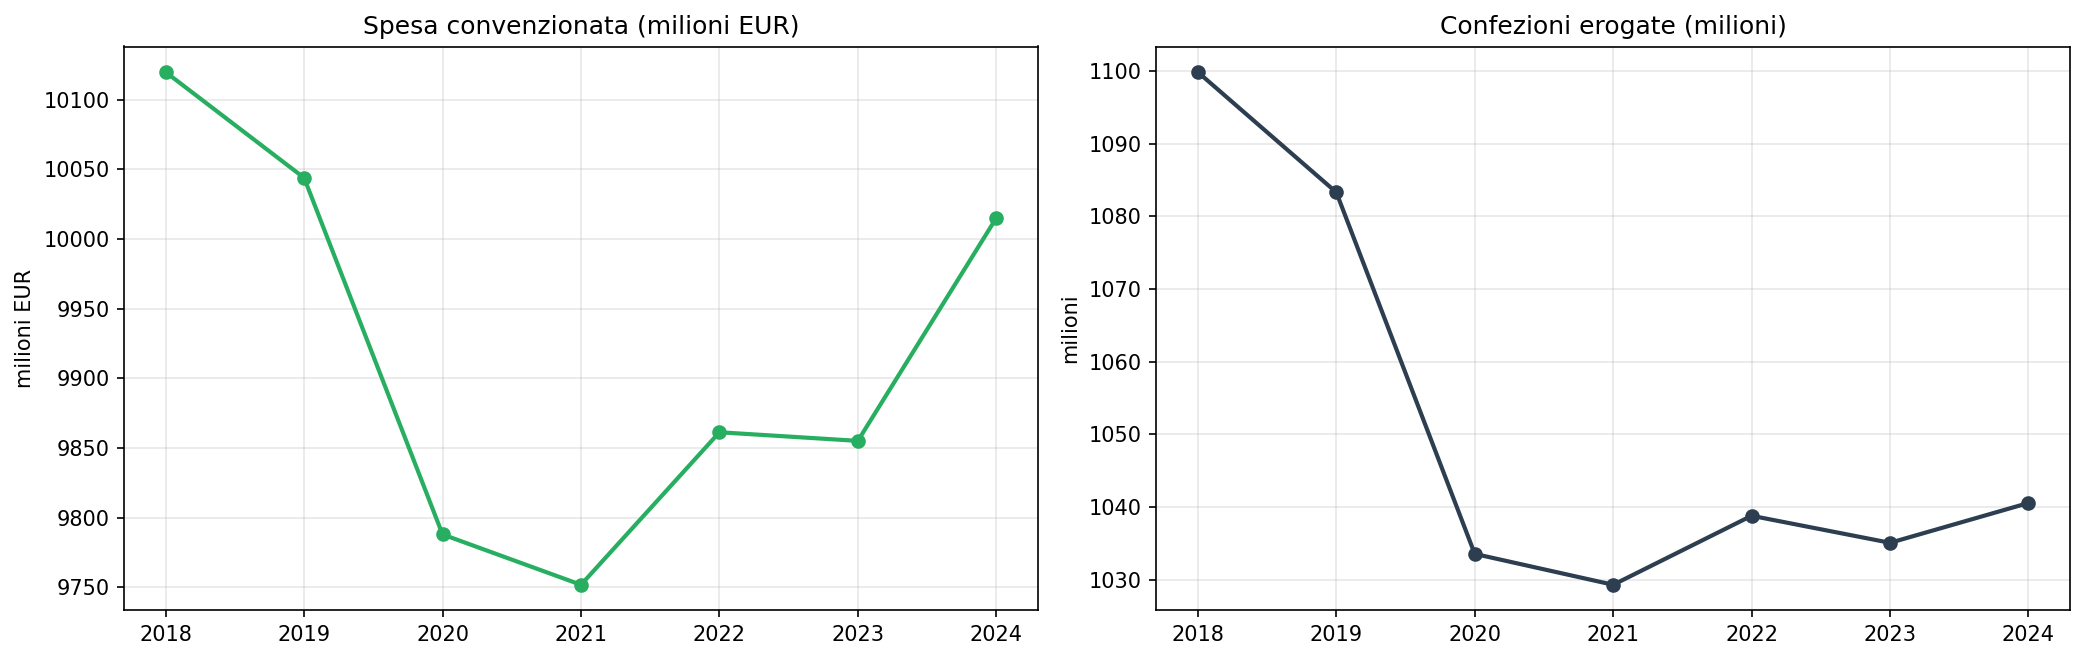

Salvato: figures/aifa_trend_nazionale.png


In [3]:
# Grafico trend
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

ax1.plot(trend['anno'], trend['spesa_M'], marker='o', linewidth=2, color='#27ae60')
ax1.set_title('Spesa convenzionata (milioni EUR)', fontsize=12)
ax1.set_ylabel('milioni EUR')
ax1.grid(alpha=0.3)

ax2.plot(trend['anno'], trend['confezioni'] / 1e6, marker='o', linewidth=2, color='#2c3e50')
ax2.set_title('Confezioni erogate (milioni)', fontsize=12)
ax2.set_ylabel('milioni')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/aifa_trend_nazionale.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvato: figures/aifa_trend_nazionale.png')

In [4]:
# 2. Spesa per categoria ATC1 (2024, classe A)
atc = con.execute(f"""
    SELECT descrizione_atc1,
           CAST(SUM(spesa_convenzionata)/1e6 AS INTEGER) AS spesa_M,
           ROUND(SUM(spesa_convenzionata) * 100.0 / SUM(SUM(spesa_convenzionata)) OVER(), 1) AS pct
    FROM read_parquet('{GCS}')
    WHERE anno = 2024 AND classe = 'A'
    GROUP BY descrizione_atc1
    ORDER BY spesa_M DESC
""").fetchdf()

display(atc)

top3 = atc.head(3)
print(f"Top 3 categorie: {top3['pct'].sum():.0f}% della spesa totale")
print(f"Cardiovascolare da solo: {top3.iloc[0]['pct']:.0f}%")

,descrizione_atc1,spesa_M,pct
0,SISTEMA CARDIOVASCOLARE,3125,31
1,APPARATO GASTROINTESTINALE E METABOLISMO,1847,18
2,SISTEMA NERVOSO,1411,14
3,SISTEMA RESPIRATORIO,940,9
4,ANTIMICROBICI GENERALI PER USO SISTEMICO,675,7
5,SANGUE ED ORGANI EMOPOIETICI,423,4
6,SISTEMA GENITO-URINARIO ED ORMONI SESSUALI,349,4
7,SISTEMA MUSCOLO-SCHELETRICO,318,3
8,FARMACI ANTINEOPLASTICI ED IMMUNOMODULATORI,271,3
9,"PREPARATI ORMONALI SISTEMICI,ESCL.ORMONI SESSU...",251,2


Top 3 categorie: 64% della spesa totale
Cardiovascolare da solo: 31%


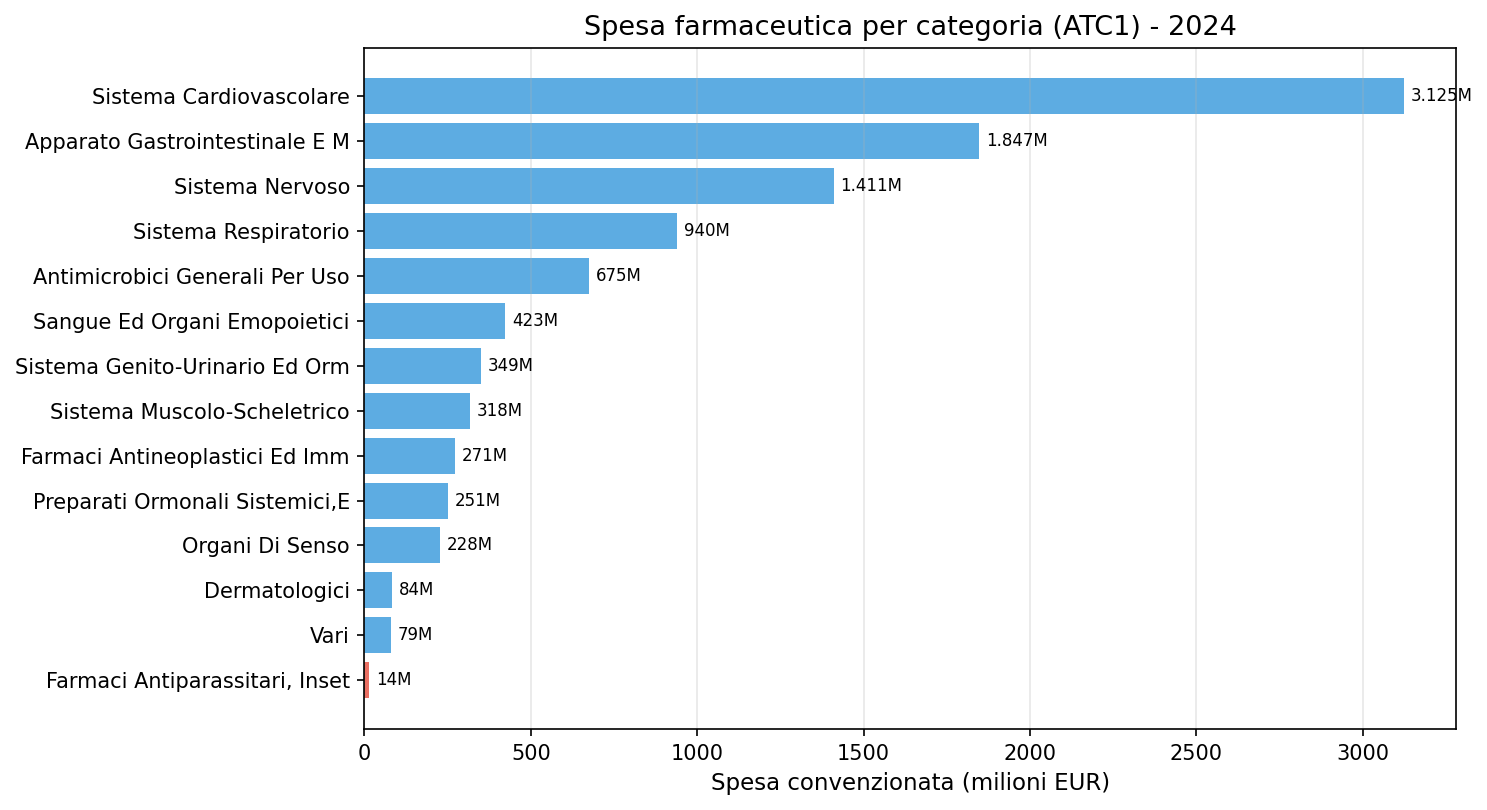

Salvato: figures/aifa_categorie_2024.png


In [5]:
# Grafico a barre categorie ATC
atc_clean = atc.copy()
atc_clean['label'] = atc_clean['descrizione_atc1'].str.title().str[:30]

fig, ax = plt.subplots(figsize=(10, 5.5))
plot_data = atc_clean.sort_values('spesa_M')
colors = ['#e74c3c' if i == plot_data.index[plot_data['spesa_M'].idxmax()] else '#3498db' for i in plot_data.index]
bars = ax.barh(plot_data['label'], plot_data['spesa_M'], color=colors, alpha=0.8)
ax.set_xlabel('Spesa convenzionata (milioni EUR)', fontsize=11)
ax.set_title('Spesa farmaceutica per categoria (ATC1) - 2024', fontsize=13)
ax.grid(alpha=0.3, axis='x')

for bar, val in zip(bars, plot_data['spesa_M']):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
            f'{val:,}M'.replace(',', '.'), va='center', fontsize=8)

plt.tight_layout()
plt.savefig('../figures/aifa_categorie_2024.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvato: figures/aifa_categorie_2024.png')

In [6]:
# 3. Spesa procapite per regione (2024)
regioni = con.execute(f"""
    SELECT regione,
           CAST(SUM(spesa_convenzionata)/1e6 AS INTEGER) AS spesa_M,
           ROUND(SUM(spesa_convenzionata) * 100.0 / SUM(SUM(spesa_convenzionata)) OVER(), 1) AS pct_nazionale
    FROM read_parquet('{GCS}')
    WHERE anno = 2024 AND classe = 'A'
    GROUP BY regione
    ORDER BY spesa_M DESC
""").fetchdf()

display(regioni)

top = regioni.iloc[0]
print(f"{top['regione']}: {top['spesa_M']}M ({top['pct_nazionale']:.0f}% del totale)")
print(f"Top 3 regioni: {regioni.iloc[0:3]['pct_nazionale'].sum():.0f}% della spesa")

,regione,spesa_M,pct_nazionale
0,LOMBARDIA,1889,19
1,CAMPANIA,1052,10
2,LAZIO,1034,10
3,SICILIA,832,8
4,PUGLIA,730,7
5,VENETO,669,7
6,PIEMONTE,633,6
7,EMILIA-ROMAGNA,609,6
8,TOSCANA,527,5
9,CALABRIA,359,4


LOMBARDIA: 1889M (19% del totale)
Top 3 regioni: 40% della spesa


,anno,spesa_C_M,pct_C
0,2018,2963,29
1,2019,2872,29
2,2020,2926,30
3,2021,2933,30
4,2022,2966,30
5,2023,3075,31
6,2024,3125,31


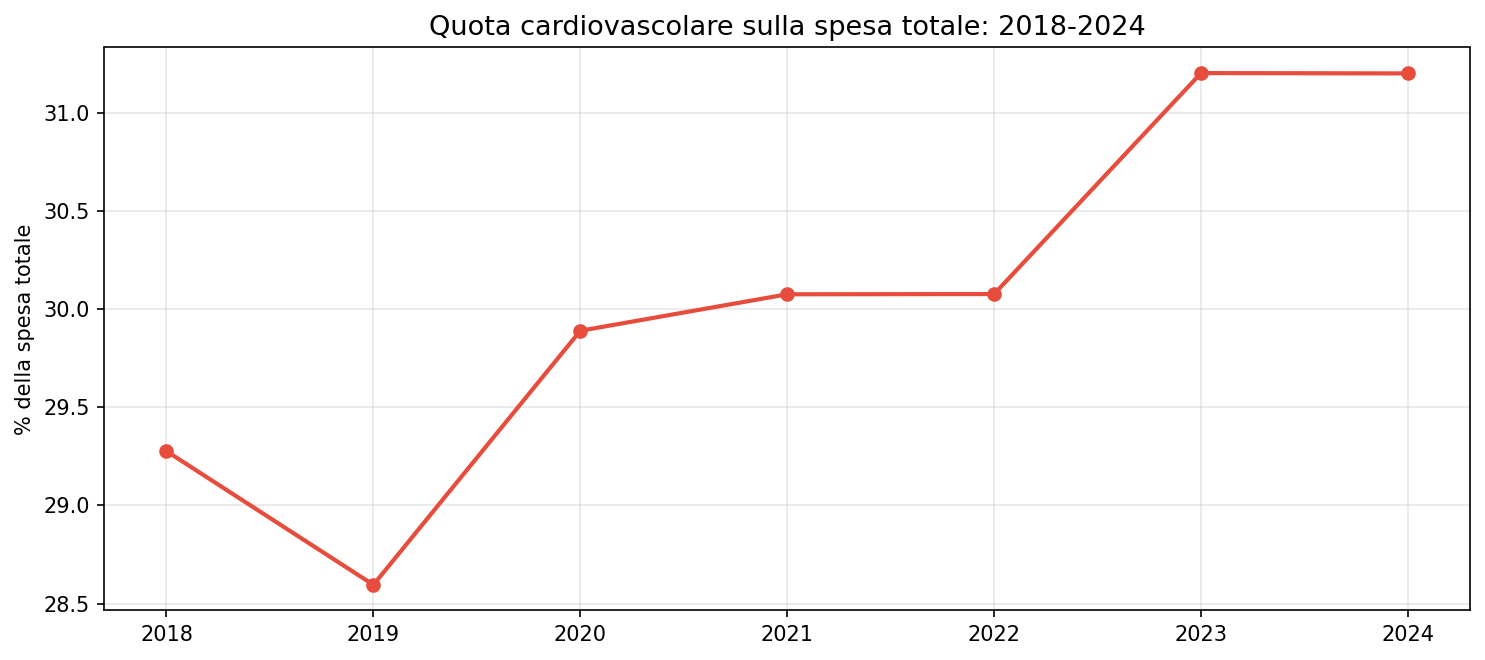

Salvato: figures/aifa_trend_cardio.png
Cardiovascolare: 29.3% (2018) -> 31.2% (2024)


In [7]:
# 4. Trend cardiovascolare (ATC C) vs totale
cardio = con.execute(f"""
    SELECT anno,
           CAST(SUM(CASE WHEN atc1 = 'C' THEN spesa_convenzionata ELSE 0 END)/1e6 AS INTEGER) AS spesa_C_M,
           CAST(SUM(CASE WHEN atc1 = 'C' THEN spesa_convenzionata ELSE 0 END) * 100.0
                / NULLIF(SUM(spesa_convenzionata), 0) AS DOUBLE) AS pct_C
    FROM read_parquet('{GCS}')
    WHERE classe = 'A'
    GROUP BY anno
    ORDER BY anno
""").fetchdf()

display(cardio)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(cardio['anno'], cardio['pct_C'], marker='o', linewidth=2, color='#e74c3c')
ax.set_title('Quota cardiovascolare sulla spesa totale: 2018-2024', fontsize=13)
ax.set_ylabel('% della spesa totale')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/aifa_trend_cardio.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvato: figures/aifa_trend_cardio.png')

c2018 = cardio[cardio['anno']==2018]['pct_C'].values[0]
c2024 = cardio[cardio['anno']==2024]['pct_C'].values[0]
print(f"Cardiovascolare: {c2018:.1f}% (2018) -> {c2024:.1f}% (2024)")

In [8]:
con.close()
print('Completato.')

Completato.
